# kNN classifier Assignment

## Business Understanding

The objective of this assignment is to build a k-Nearest Neighbors (kNN) classifier to predict whether a breast tumor is benign or malignant based on various features extracted from digitized images of fine needle aspirate (FNA) of breast mass. The dataset used to accomplish this task is the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository.

The model will be evaluated based on its accuracy and confusion matrix to verify its performance in classifying tumors correctly. The accuracy of the model is vital as classifying malignant tumors as benign could have fatal consequences for patients. Furthermore, the model should also aim to minimize false positives as well, to avoid unnecessary anxiety and medical procedures for patients.

## Data Understanding

The data used in this assignment is the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository. The dataset contains 569 datapoints, each representing a breast tumor. Each datapoint has 32 values, 30 of which are gathered from digitized images of fine needle aspirate (FNA) of the breast mass.

Below you can find the variables in the dataset:
- ID: Unique identifier for each patient
- Radius: Mean of distances from center to points on the perimeter
- Texture: Standard deviation of gray-scale values
- Perimeter: Mean size of the core tumor
- Area: Mean area of the tumor
- Smoothness: Mean of local variation in radius lengths
- Compactness: Mean of perimeter^2 / area - 1.0
- Concavity: Mean of severity of concave portions of the contour
- Concave points: The number of concave portions of the contour
- Symmetry: Mean of symmetry of the tumor
- Fractal dimension: Mean of "coastline approximation" - 1
- Diagnosis: The diagnosis of breast tissue (M = malignant, B = benign)

In [52]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

df = breast_cancer_wisconsin_diagnostic.data.original

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactness2       

## Data Preparation

The dataset is already clean and does not contain any missing values and so no cleaning is necessary. The preparation then only involves scaling the features to ensure that they are on the same scale. This is important for the kNN algorithm as unscaled features would lead to biased results favoring features with larger values.

An important step in the preparation is to separate the features form the target variable, which in this case is whether the tumor is benign or malignant. Finally, the ID column is dropped as it does not provide any useful data for hte classification.

In [53]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Diagnosis', 'ID'])
y = df['Diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modeling

With the data prepared, it can now be split into training and testing sets. The training set will be used to train the kNN classifier, while the testing set will be used to evaluate its performance. In this case, 30% of the data was used for testing.

Several hyperparameters for the number of neighbors (k) were used to train different models, and the accuracy of each model was evaluated. The value of k that yielded the highest accuracy was selected for the final evaluation.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    print(f"Accuracy: {accuracy} (k={k})")

Accuracy: 0.9590643274853801 (k=1)
Accuracy: 0.9707602339181286 (k=2)
Accuracy: 0.9883040935672515 (k=3)
Accuracy: 0.9883040935672515 (k=4)
Accuracy: 0.9883040935672515 (k=5)
Accuracy: 0.9883040935672515 (k=6)
Accuracy: 0.9941520467836257 (k=7)
Accuracy: 0.9883040935672515 (k=8)
Accuracy: 0.9883040935672515 (k=9)
Accuracy: 0.9883040935672515 (k=10)


## Evaluation

In this case, the model with k=7 yielded the highest accuracy of approximately 99.42%. This model was then selected for the final evaluation using a confusion matrix to visualize its performance in classifying tumors correctly. Since the dataset contains 30 features the k=7 model should be able to capture the complexity of the data well enough without overfitting.

Below is the code for generating the confusion matrix for the k=7 model.

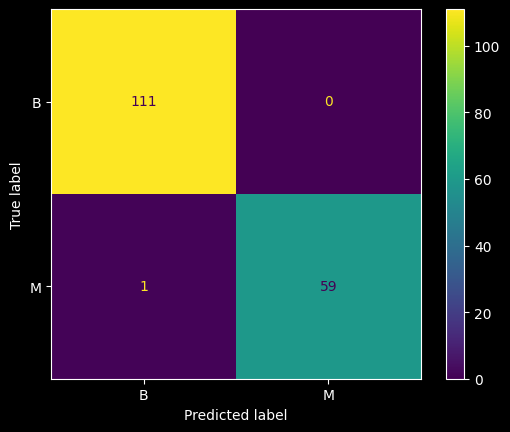

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
cmd.plot()
plt.show()

In [56]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           B       0.99      0.99      0.99       111
           M       0.98      0.98      0.98        60

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



As can be seen from the confusion matrix, the model classified 111 benign tumors and 59 malignant tumors correctly, with only 1 false negative and without any false positives. Accuracy of this model is calculated to be 99% while precision was 99% and 98% for benign and malignant tumors respectively. While recall was also 99% and 98% for benign and malignant tumors respectively. Overall, the kNN classifier with k=7 performed as expected and demonstrated its effectiveness in classifying breast tumors based on the given features.

## Deployment

If this model were to be deployed in a real-world scenario, it could be integrated into a healthcare system where medical professionals could input the features of a breast tumor and receive a prediction on whether it is benign or malignant. This could aid in early detection and treatment of breast cancer. Though, it is important to note that this model should not be used as the definitive diagnosis but rather as a supporting tool for medical professionals.

The deployment would however require further validation and testing on a much larger and more diverse dataset to ensure its functionality and reliability. Along with regular monitoring and updating the model to maintain its performance and accuracy over time.